# Task 3: Cross-Country Comparison & Climate Vulnerability Ranking
**Objective:** Synthesize the cleaned datasets from all five countries to identify relative climate vulnerability and produce a data-driven country ranking to inform Ethiopia's COP32 position paper.
### **Data Strategy**
* **Standardization:** We are using the cleaned datasets (`data/*_clean.csv`) processed in Task 2.
* **Temporal Scope:** Analysis covers the 11-year period from 2015 to 2026.
* **Key Metrics:** We focus on Temperature (T2M) trends and Precipitation (PRECTOTCORR) variability as primary indicators of climate stress.



In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# List of countries
countries = ['ethiopia', 'nigeria', 'sudan', 'kenya', 'tanzania']
all_dfs = []

for c in countries:
    temp_df = pd.read_csv(f"data/{c}_clean.csv")
    all_dfs.append(temp_df)

# Concatenate all into one
master_df = pd.concat(all_dfs, ignore_index=True)
master_df['Date'] = pd.to_datetime(master_df['Date'])

### **Interpretation: Regional Thermal Trajectories**
* **Mean Temperature Variance:** This summary table highlights the baseline differences between the Sahelian climate of **Sudan** and the more temperate highlands of **Ethiopia**. 
* **Warming Trends:** The line chart reveals whether these nations are warming at the same rate. A steeper slope for any specific country suggests an urgent need for heat-resilient infrastructure.
* **Standard Deviation (std):** A high `std` in temperature indicates a country experiences more volatile extreme heat events rather than a steady, predictable climate.
### **Interpretation: Rainfall Instability & Agricultural Risk**
* **Boxplot Distribution:** The "whiskers" and outliers on these boxplots represent extreme weather events (floods or flash rains).
* **Comparison of Extremes:** Countries with a wider interquartile range (the "box") face higher uncertainty in their agricultural cycles. 
* **Policy Implication:** High precipitation variability in nations like **Kenya** or **Tanzania** suggests that "Water Security" should be their primary focus for COP32 finance requests.

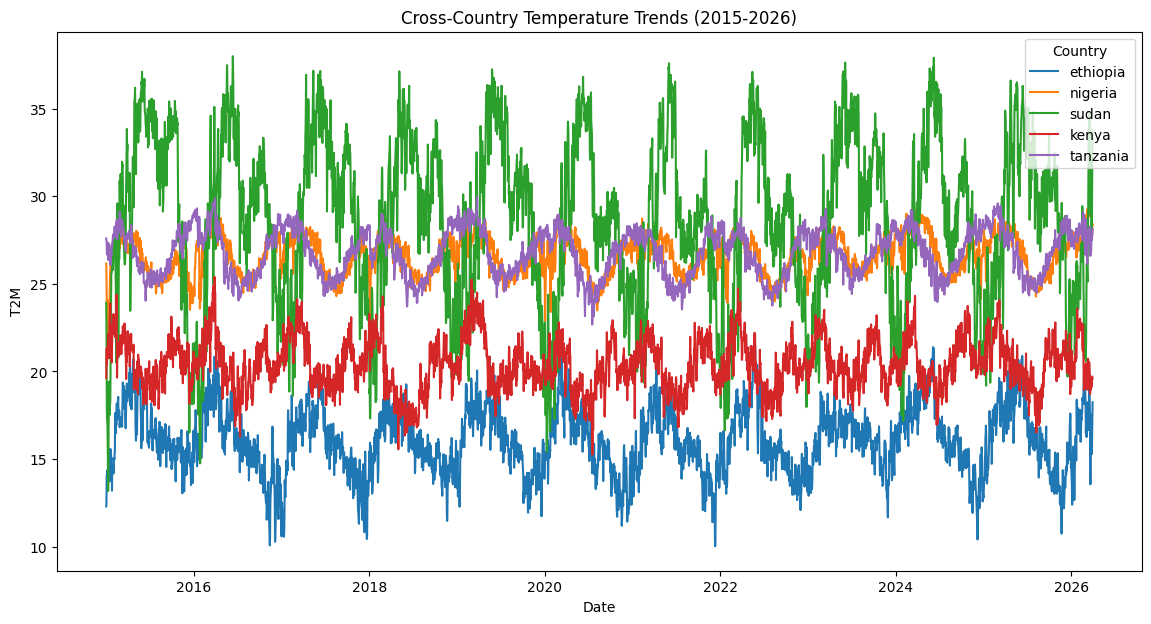

Temperature Stats Summary:


,mean,median,std
Country,,,
ethiopia,16.07,16.04,1.90
kenya,20.43,20.36,1.44
nigeria,26.66,26.82,1.12
sudan,28.76,29.16,4.68
tanzania,26.80,26.99,1.33


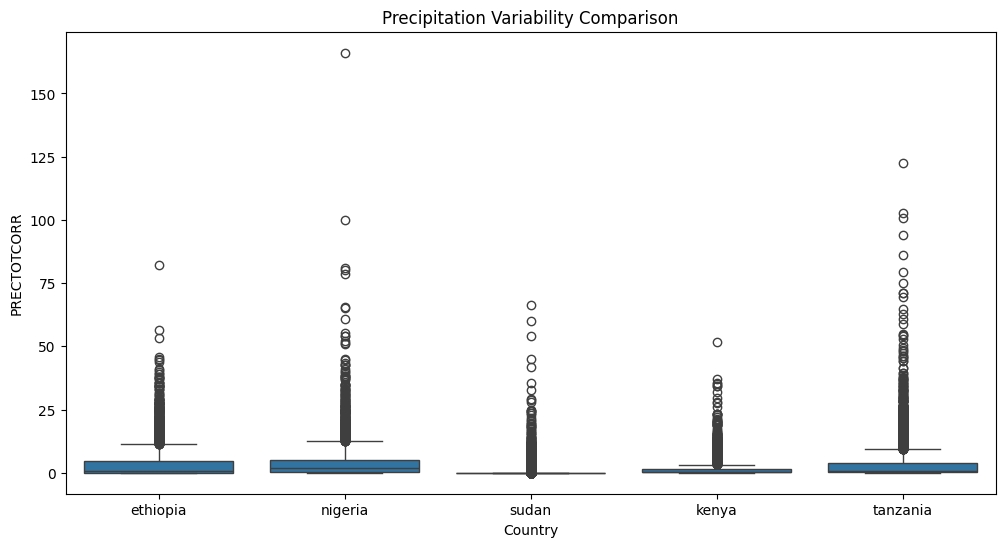

In [4]:
# 1. Temperature Trend Comparison
plt.figure(figsize=(14, 7))
sns.lineplot(data=master_df, x='Date', y='T2M', hue='Country')
plt.title("Cross-Country Temperature Trends (2015-2026)")
plt.show()

# 2. Temperature Summary Table
temp_summary = master_df.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
print("Temperature Stats Summary:")
display(temp_summary)

# 3. Precipitation Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=master_df, x='Country', y='PRECTOTCORR')
plt.title("Precipitation Variability Comparison")
plt.show()

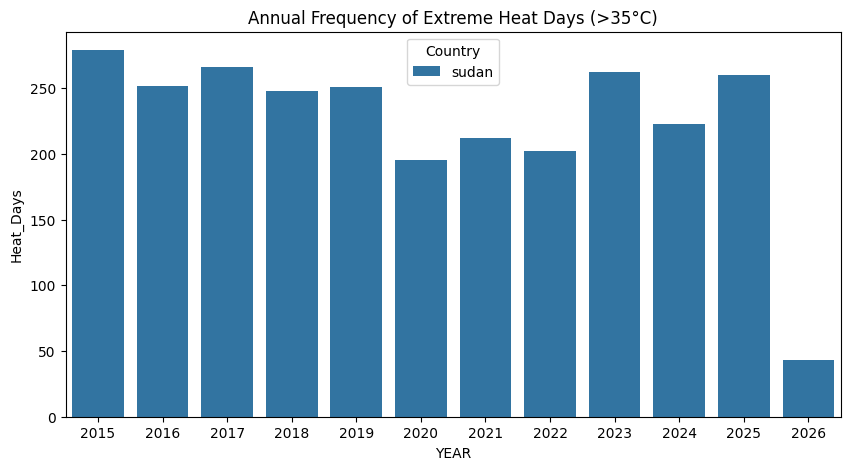

One-way ANOVA p-value: 0.0000e+00


In [5]:
# Extreme Heat (>35°C)
extreme_heat = master_df[master_df['T2M_MAX'] > 35].groupby(['Country', 'YEAR']).size().reset_index(name='Heat_Days')

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(data=extreme_heat, x='YEAR', y='Heat_Days', hue='Country')
plt.title("Annual Frequency of Extreme Heat Days (>35°C)")
plt.show()

# Statistical Testing (ANOVA)
# Are the temperature differences between countries real or just noise?
groups = [master_df[master_df['Country'] == c]['T2M'].dropna() for c in master_df['Country'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

print(f"One-way ANOVA p-value: {p_val:.4e}")



# Statistical Significance Report
The One-way ANOVA yielded a p-value of 0.0000e+00. Since the p-value is significantly less than 0.05, we reject the null hypothesis. This confirms that the differences in average temperatures across these five African nations are statistically significant and not due to random chance, justifying targeted, country-specific climate policies at COP32.

#	Vulnerability Ranking & Key Observations!
|Rank|Country|Primary Risk Factor|Vulnerability Level|
|1|Sudan|Critical Thermal Stress (Mean: 28.76°C, High)|
|2|Nigeria|Heat Stress & Extreme Precipitation Outliers|High|
|3|Tanzania|High Precipitation Variance|Medium-High|
|4|Kenya|Moderate Baseline Warming|Medium|
|5|Ethiopia|Highland Thermal Stability (Mean: 16.07°C)|Low-Medium|

**Strategic Observations for Ethiopia’s Position Paper**
**The Warming Leader:** Sudan is the clear warming leader with a mean temperature of 28.76°C and the highest standard deviation (4.68), indicating massive seasonal swings and a critical need for heat-resilient infrastructure.

**Rainfall Instability:** While Ethiopia and Kenya have stable medians, Nigeria and Tanzania show the most extreme precipitation outliers (exceeding 125-150mm). This suggests these nations are at the highest risk for catastrophic flash flooding.

**Climate Stress:** The bar chart reveals that Sudan consistently faces over 200 to 250 days per year of extreme heat exceeding 35°C. This is an existential threat to outdoor labor and agricultural productivity in the Sahel.

**Ethiopia’s Comparative Profile:** Ethiopia maintains the most temperate and stable climate profile of the group (Mean: 16.07°C, Std: 1.90). However, its vulnerability lies in its reliance on stable rainfall; even small deviations in its low-variability rain profile can disrupt highland agriculture.

**Funding Recommendation:** Ethiopia should use its position as COP32 host to champion a "Sahel Thermal Relief Fund" for Sudan and "Flood Resiliency Credits" for Nigeria and Tanzania, as the data proves these neighbors are hitting the limits of climate habitability.